# Controlling Several Real Actuators

This example demonstrates how to control multiple PULSAR HRI actuators. We will walk through the steps of connecting to the CAN to USB adapter, initializing two actuators, configuring their feedback settings, assigning different speed setpoints, and running them simultaneously.

The physical connection for this example (two actuators and the CAN to USB adapter) is shown in the image below. The actuators are connected to the CAN bus via an adapter, which is connected to the host computer via USB.

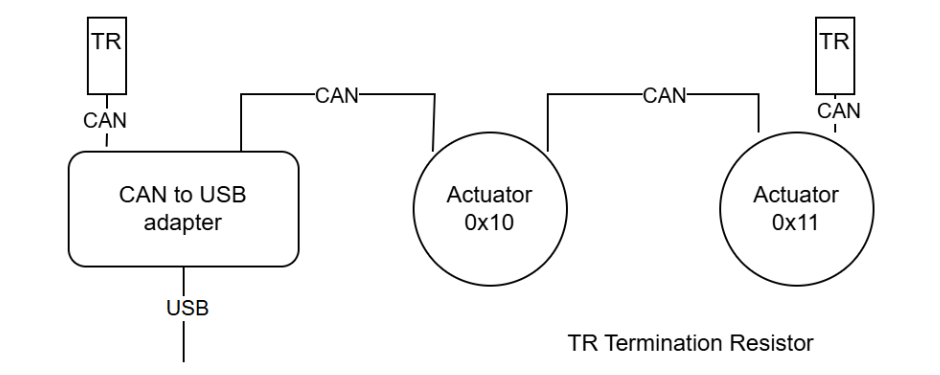

> Warning: Do not forget the termination resistors (TR) at the ends of the CAN bus.

The schema shows actuators with addresses `0x10` and `0x11`, but you need to find out the actual addresses of your devices. For that you can either use the [CLI scan command](cli.md#scan-for-devices) or use the Desktop App to change their address.

## Import necessary modules


In [ ]:
from pcp_api import PCP_over_USB, PulsarActuator
from time import sleep


## Instantiate the adapter

We are going to create a list with all the actuators we want to control, and instantiate a single adapter for all of them. If only one adapter is connected to the computer, you can use the `get_port()` method to automatically detect the USB port. You can also specify the port manually (for example, `"COM1"` on Windows or `"/dev/ttyACM0"` on Linux).


In [ ]:
ACTUATOR_ADDRESSES = [0x10, 0x11]  # Use the actual addresses of your actuators

# Auto-detect CAN to USB adapter port
port = PCP_over_USB.get_port()
# port = "COM1"
print(f"Connecting to {port}")
adapter = PCP_over_USB(port)


## Define a feedback callback function

This function is called automatically whenever feedback is received from any actuator. You can define individual functions for each actuator, or use a single function for all actuators. In this example, we extract the position from the feedback dictionary and print it along with the actuator address.


In [ ]:
def actuator_feedback(address: int, feedback: dict):
    position = feedback.get(PulsarActuator.PCP_Items.POSITION_FB, None)
    print(f"Actuator 0x{address:X} position: {position:.2f} rad/s")


## Initialize actuators and set common configuration

We create a loop to initialize each actuator using its address. Each actuator is connected, configured for high-frequency feedback, and set to `SPEED` mode. The same feedback callback function is registered to handle incoming feedback from the actuators.


In [ ]:
actuators = []  # list to hold actuator instances

for address in ACTUATOR_ADDRESSES:
    # Create a PulsarActuator instance.
    actuator = PulsarActuator(adapter, address)

    # Attempt to connect to the actuator.
    if not actuator.connect():
        print(f"Could not connect to the actuator {actuator.address}")
        adapter.close()
        raise SystemExit(1)

    print(f"Connected to the actuator {actuator.address} (model: {actuator.model}, firmware: {actuator.firmware_version})")

    # Configure high-frequency feedback to report position at 10 Hz.
    actuator.setFeedbackItems([
        PulsarActuator.PCP_Items.POSITION_FB,
        # Add other items if needed
    ])
    actuator.setFeedbackRate(actuator.Rates.RATE_10HZ)

    # Set the actuator to SPEED mode.
    actuator.change_mode(PulsarActuator.Mode.SPEED)

    # Register the feedback callback function.
    actuator.set_feedback_callback(actuator_feedback)

    # Add the actuator to the list.
    actuators.append(actuator)


## Individual actuator configuration

We assign different configuration to each actuator. In this case, only the speed setpoint is different.


In [ ]:
# Set different speeds for each actuator
actuators[0].change_setpoint(0.2)  # rad/s
actuators[1].change_setpoint(0.3)  # rad/s


## Run and cleanup

We start all actuators and let them run. The feedback will be printed in the console. When the program is interrupted, we ensure all actuators are properly disconnected and the adapter is closed.


In [ ]:
# Start all actuators
for actuator in actuators:
    actuator.start()

print("Actuators started. Press Stop to interrupt.")
try:
    while True:
        sleep(0.1)  # Let feedback trigger
except KeyboardInterrupt:
    pass
finally:
    for actuator in actuators:
        actuator.disconnect()
    sleep(0.1)
    adapter.close()
